In [11]:
# Re-import everything necessary after kernel context loss
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
# Load JSON data
def load_json_data(json_path):
    with open(json_path) as file:
        return json.load(file)


# Flatten the structured JSON into a DataFrame
def flatten_data(results_data, experiment_type=None):
    records_list = []
    for dataset_name, model_dict in results_data.items():
        for model_name, records in model_dict.items():
            for r in records:
                method = r.get("method", "unknown")
                records_list.append(
                    {
                        "dataset": dataset_name,
                        "model_name": model_name,
                        "distance_name": r["distance_name"],
                        "distance_type": r.get("distance_type", "vector"),
                        "pca_applied": r.get("pca_applied", False),
                        "method": method,
                        "drift_strength": r["drift_strength"],
                        "final_similarity": r["final_similarity"],
                        "avg_overhead": r.get("avg_overhead", float("nan")),
                        "time_taken": r.get("time_taken", float("nan")),
                        "avg_memory_mb": r.get("avg_memory_mb", float("nan")),
                        "peak_memory_mb": r.get(
                            "peak_memory_mb", r.get("avg_memory_mb", float("nan"))
                        ),
                        "experiment_type": experiment_type,
                    }
                )
    return pd.DataFrame(records_list)

In [13]:
# Load newly uploaded JSONs with distinct names
vector_data = load_json_data(
    "/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/vector_experiment/2025-04-15_19-16-28/results.json"
)
distribution_data = load_json_data(
    "/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/distribution_experiment/2025-04-11_07-51-52/results.json"
)

# Flatten both with appropriate experiment_type
df_vector = flatten_data(vector_data, experiment_type="vector")
df_distribution = flatten_data(distribution_data, experiment_type="distribution")

# Combine into a single DataFrame
combined_df = pd.concat([df_vector, df_distribution], ignore_index=True)

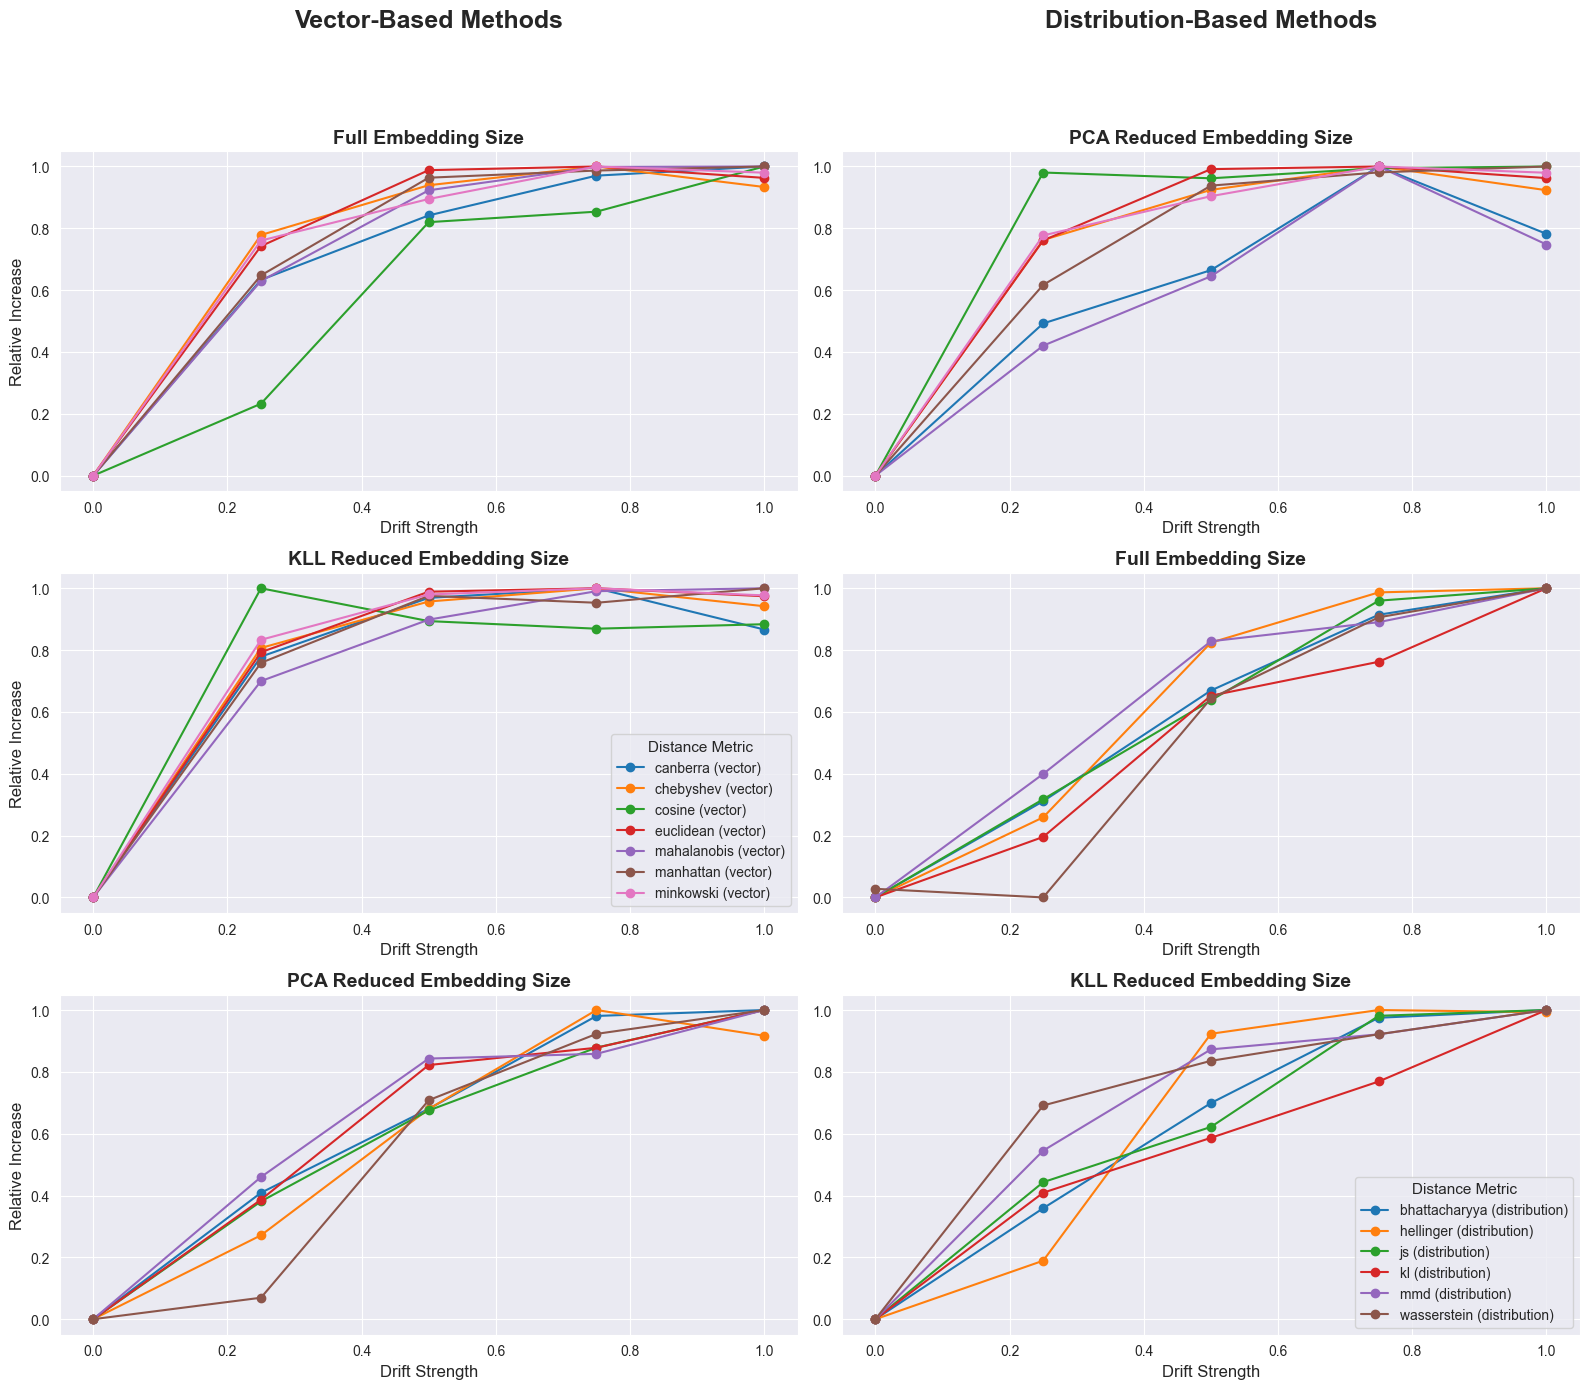

Plot saved to: /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_relative_log_increase_6subplots.png


In [27]:
def plot_relative_log_increase(
    df,
    output_dir="/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment",
):
    plot_data = []

    for _, row in df.iterrows():
        if row["drift_strength"] >= 0:
            base_similarity_filter = [
                (df["drift_strength"] == 0),
                (df["distance_name"] == row["distance_name"]),
                (df["method"] == row["method"]),
            ]
            if "experiment_type" in df.columns and row["experiment_type"] is not None:
                base_similarity_filter.append(
                    df["experiment_type"] == row["experiment_type"]
                )

            base_similarity = df.loc[np.logical_and.reduce(base_similarity_filter)][
                "final_similarity"
            ].mean()

            if base_similarity and base_similarity > 0:
                rel_log = np.log(row["final_similarity"] / base_similarity)
                plot_data_row = {
                    "distance_name": row["distance_name"],
                    "drift_strength": row["drift_strength"],
                    "method": row["method"],
                    "distance_type": row["distance_type"],
                    "rel_log_increase": rel_log,
                }
                if "experiment_type" in df.columns:
                    plot_data_row["experiment_type"] = row["experiment_type"]
                plot_data.append(plot_data_row)

    df_plot = pd.DataFrame(plot_data)

    df_normalized = []
    groupby_cols = ["distance_name", "method"]
    if "experiment_type" in df_plot.columns:
        groupby_cols.append("experiment_type")

    for group_key, group in df_plot.groupby(groupby_cols):
        df_avg = (
            group.groupby("drift_strength")["rel_log_increase"].mean().reset_index()
        )
        min_val = df_avg["rel_log_increase"].min()
        max_val = df_avg["rel_log_increase"].max()
        if max_val - min_val > 1e-12:
            df_avg["normalized"] = (df_avg["rel_log_increase"] - min_val) / (
                max_val - min_val
            )
        else:
            df_avg["normalized"] = 0.0

        if "experiment_type" in df_plot.columns:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]
            df_avg["experiment_type"] = group_key[2]
        else:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]

        df_avg["distance_type"] = group["distance_type"].iloc[0]
        df_normalized.append(df_avg)

    df_final = pd.concat(df_normalized, ignore_index=True)

    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(4, 2, height_ratios=[0.1, 1, 1, 1])

    method_positions = {
        (0, 0): "no_pca",
        (0, 1): "pca",
        (1, 0): "kll_vector",
        (1, 1): "histogram",
        (2, 0): "pca_histogram",
        (2, 1): "kll_distribution",
    }

    title_map = {
        "no_pca": "Full Embedding Size",
        "pca": "PCA Reduced Embedding Size",
        "kll_vector": "KLL Reduced Embedding Size",
        "histogram": "Full Embedding Size",
        "pca_histogram": "PCA Reduced Embedding Size",
        "kll_distribution": "KLL Reduced Embedding Size",
    }

    vector_title_ax = fig.add_subplot(gs[0, 0])
    vector_title_ax.set_title("Vector-Based Methods", fontsize=18, fontweight="bold")
    vector_title_ax.axis("off")

    dist_title_ax = fig.add_subplot(gs[0, 1])
    dist_title_ax.set_title(
        "Distribution-Based Methods", fontsize=18, fontweight="bold"
    )
    dist_title_ax.axis("off")

    subplot_positions = {
        (0, 0): (1, 0),
        (0, 1): (1, 1),
        (1, 0): (2, 0),
        (1, 1): (2, 1),
        (2, 0): (3, 0),
        (2, 1): (3, 1),
    }

    axes = {}
    for pos, method in method_positions.items():
        subplot_pos = subplot_positions[pos]
        ax = fig.add_subplot(gs[subplot_pos])
        axes[pos] = ax

        sub_df = df_final[df_final["method"] == method]

        if "experiment_type" in sub_df.columns:
            for dist_name in sub_df["distance_name"].unique():
                for exp_type in sub_df["experiment_type"].unique():
                    d = sub_df[
                        (sub_df["distance_name"] == dist_name)
                        & (sub_df["experiment_type"] == exp_type)
                    ]
                    if not d.empty:
                        label = f"{dist_name} ({exp_type})" if exp_type else dist_name
                        ax.plot(
                            d["drift_strength"],
                            d["normalized"],
                            marker="o",
                            label=label,
                        )
        else:
            for dist_name in sub_df["distance_name"].unique():
                d = sub_df[sub_df["distance_name"] == dist_name]
                if not d.empty:
                    ax.plot(
                        d["drift_strength"],
                        d["normalized"],
                        marker="o",
                        label=dist_name,
                    )

        ax.set_title(
            title_map.get(method, f"Method: {method}"), fontsize=14, fontweight="bold"
        )
        ax.set_xlabel("Drift Strength", fontsize=12)
        ax.grid(True)

        if pos[1] == 0:
            ax.set_ylabel("Relative Increase", fontsize=12)

        if (
            method in ["kll_vector", "kll_distribution"]
            and ax.get_legend_handles_labels()[0]
        ):
            ax.legend(title="Distance Metric", fontsize=10, title_fontsize=11)

    plt.tight_layout()

    path_out = os.path.join(output_dir, "plot_relative_log_increase_6subplots.png")
    plt.savefig(path_out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return path_out


# Generate plot
output_plot_path = plot_relative_log_increase(combined_df)
print(f"Plot saved to: {output_plot_path}")

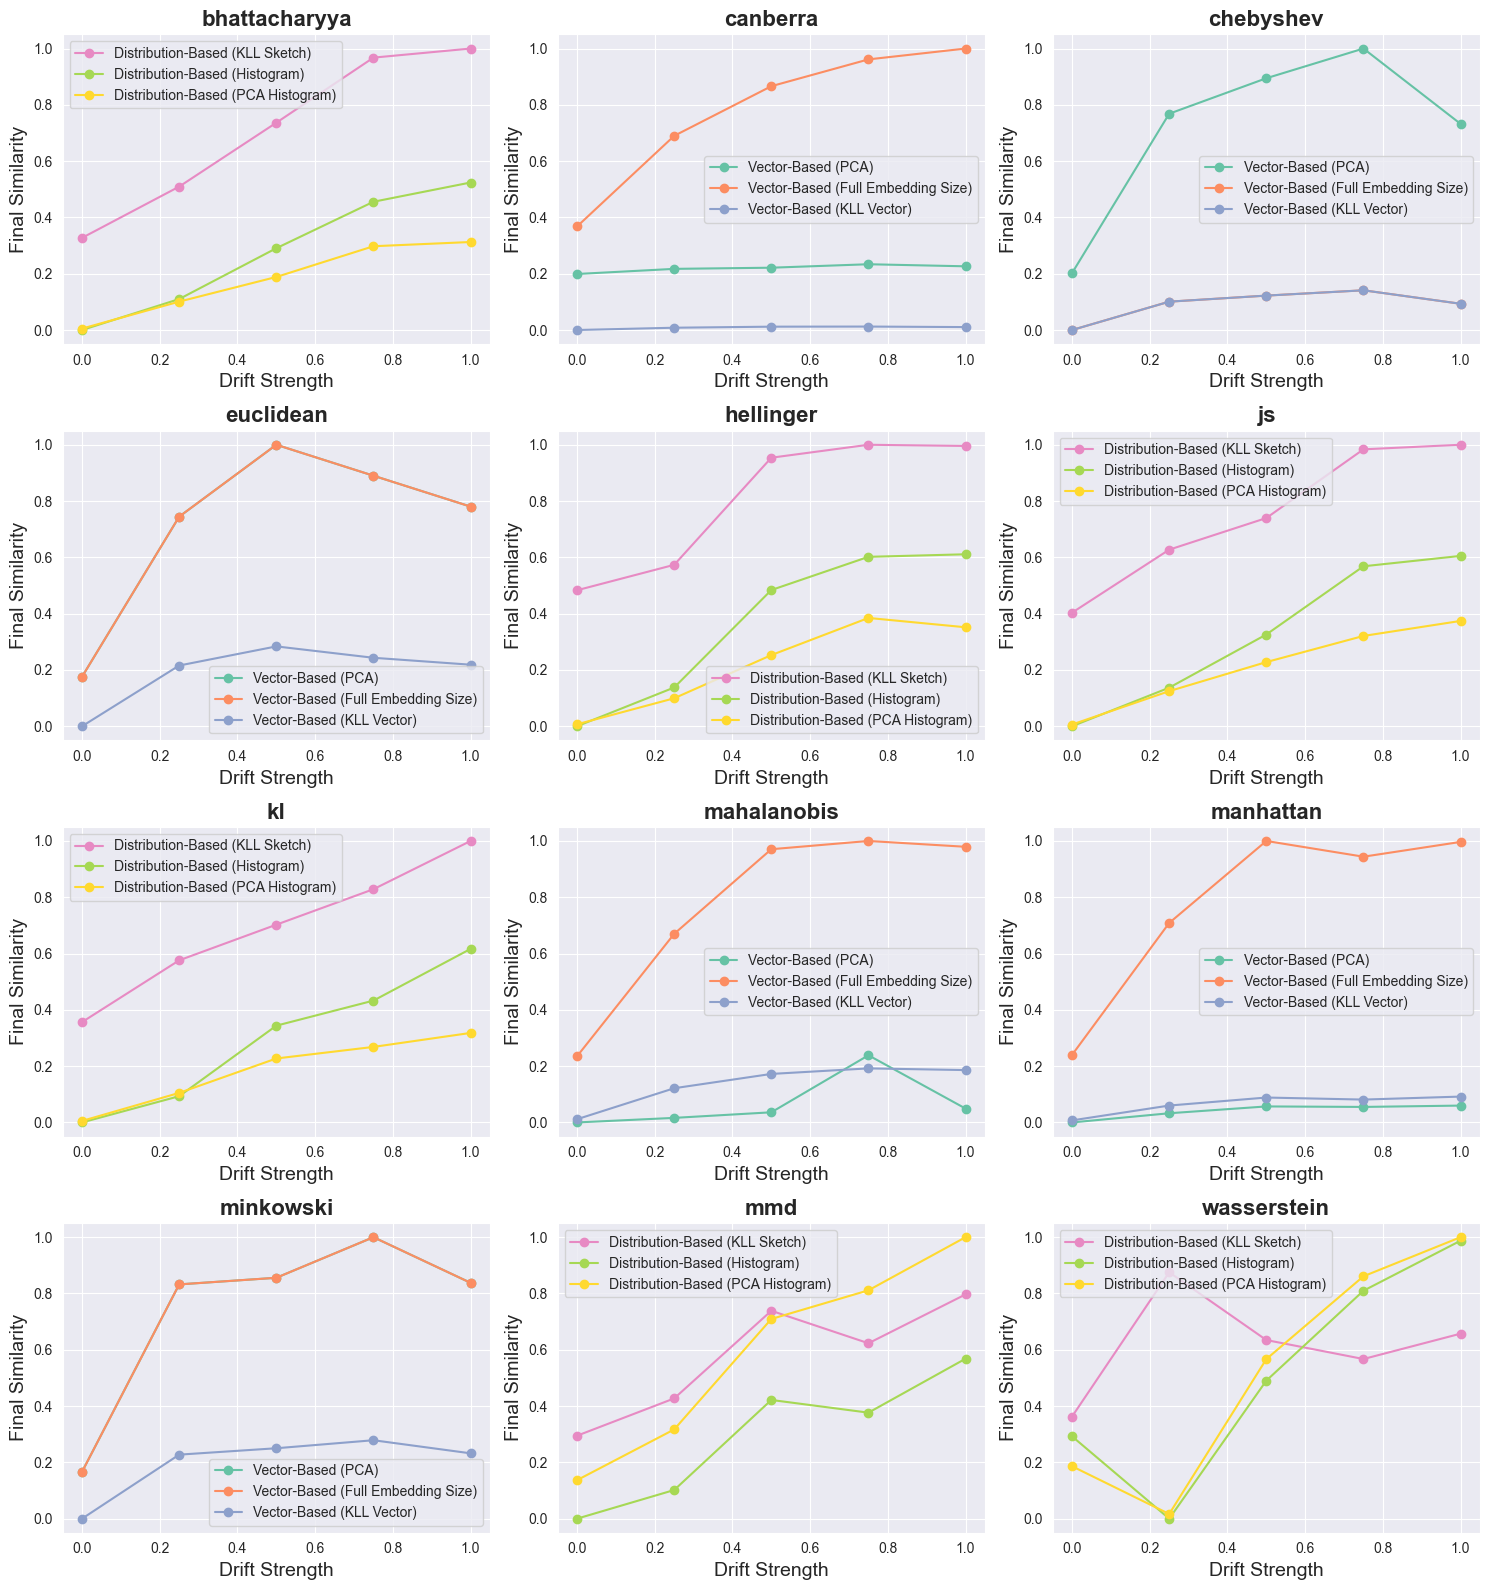

[Saved] /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_final_similarity_all_methods_by_distance.png


In [36]:
import seaborn as sns


def plot_final_similarity_separate(df, output_dir):
    """Creates subplots with a maximum of 3 plots per column, excluding the "cosine" distance metric."""
    # Step 1: Filter out "cosine" distance metric
    df = df[df["distance_name"] != "cosine"]

    # Step 2: Compute mean final_similarity for each group
    df_sim = df.groupby(
        ["distance_name", "drift_strength", "method", "experiment_type"], as_index=False
    )["final_similarity"].mean()

    # Step 3: Normalize final similarity within each distance metric
    df_sim["final_similarity_norm"] = 0.0
    for dist_name, group_data in df_sim.groupby("distance_name"):
        min_val = group_data["final_similarity"].min()
        max_val = group_data["final_similarity"].max()
        if max_val - min_val == 0:
            df_sim.loc[group_data.index, "final_similarity_norm"] = 0.0
        else:
            df_sim.loc[group_data.index, "final_similarity_norm"] = (
                group_data["final_similarity"] - min_val
            ) / (max_val - min_val)

    # Step 4: Prepare subplots with a maximum of 3 plots per column
    unique_distances = sorted(df_sim["distance_name"].unique())
    num_dists = len(unique_distances)
    num_cols = 3
    num_rows = int(np.ceil(num_dists / num_cols))

    fig, axes = plt.subplots(
        num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False
    )
    palette = sns.color_palette("Set2", 6)  # 6 colors for all methods

    # Define method labels
    method_labels = {
        "pca": "Vector-Based (PCA)",
        "no_pca": "Vector-Based (Full Embedding Size)",
        "kll_vector": "Vector-Based (KLL Vector)",
        "kll_distribution": "Distribution-Based (KLL Sketch)",
        "histogram": "Distribution-Based (Histogram)",
        "pca_histogram": "Distribution-Based (PCA Histogram)",
    }

    # Step 5: Plot each distance
    for idx, dist_name in enumerate(unique_distances):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row][col]

        # Include all vector and distribution methods
        all_methods = [
            "pca",
            "no_pca",
            "kll_vector",
            "kll_distribution",
            "histogram",
            "pca_histogram",
        ]

        for i, method in enumerate(all_methods):
            subset = df_sim[
                (df_sim["distance_name"] == dist_name) & (df_sim["method"] == method)
            ]
            if not subset.empty:
                ax.plot(
                    subset["drift_strength"],
                    subset["final_similarity_norm"],
                    marker="o",
                    label=method_labels.get(method, method),
                    color=palette[i % len(palette)],
                )

        ax.set_title(dist_name, fontsize=16, fontweight="bold")
        ax.set_xlabel("Drift Strength", fontsize=14)
        ax.set_ylabel("Final Similarity", fontsize=14)
        ax.grid(True)
        ax.legend()

    # Step 6: Remove unused axes
    for i in range(num_dists, num_rows * num_cols):
        row, col = i // num_cols, i % num_cols
        if row < len(axes) and col < len(axes[0]):
            fig.delaxes(axes[row][col])

    plt.tight_layout()
    path_sim = os.path.join(
        output_dir, "plot_final_similarity_all_methods_by_distance.png"
    )
    plt.savefig(path_sim)
    plt.show()
    plt.close()
    print(f"[Saved] {path_sim}")


plot_final_similarity_separate(
    combined_df,
    "/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment",
)

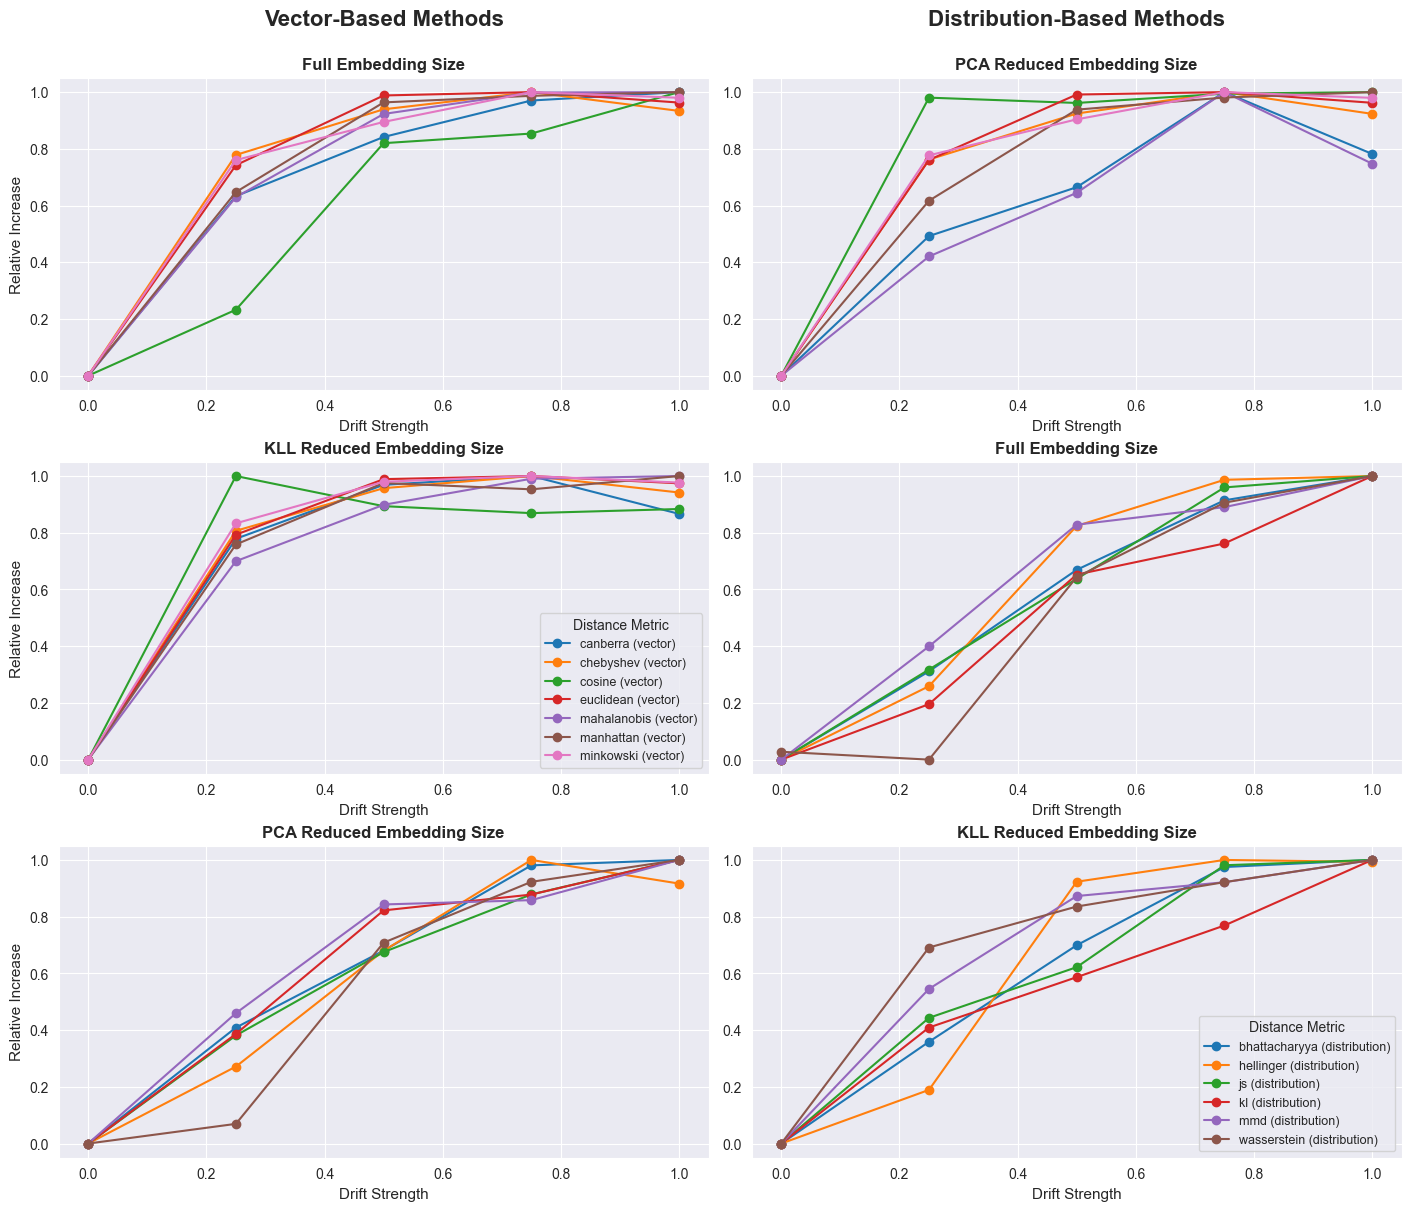

Plot saved to: /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_relative_log_increase_6subplots.png


In [28]:
def plot_relative_log_increase(
    df,
    output_dir="/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment",
):
    plot_data = []

    for _, row in df.iterrows():
        if row["drift_strength"] >= 0:
            base_similarity_filter = [
                (df["drift_strength"] == 0),
                (df["distance_name"] == row["distance_name"]),
                (df["method"] == row["method"]),
            ]
            if "experiment_type" in df.columns and row["experiment_type"] is not None:
                base_similarity_filter.append(
                    df["experiment_type"] == row["experiment_type"]
                )

            base_similarity = df.loc[np.logical_and.reduce(base_similarity_filter)][
                "final_similarity"
            ].mean()

            if base_similarity and base_similarity > 0:
                rel_log = np.log(row["final_similarity"] / base_similarity)
                plot_data_row = {
                    "distance_name": row["distance_name"],
                    "drift_strength": row["drift_strength"],
                    "method": row["method"],
                    "distance_type": row["distance_type"],
                    "rel_log_increase": rel_log,
                }
                if "experiment_type" in df.columns:
                    plot_data_row["experiment_type"] = row["experiment_type"]
                plot_data.append(plot_data_row)

    df_plot = pd.DataFrame(plot_data)

    df_normalized = []
    groupby_cols = ["distance_name", "method"]
    if "experiment_type" in df_plot.columns:
        groupby_cols.append("experiment_type")

    for group_key, group in df_plot.groupby(groupby_cols):
        df_avg = (
            group.groupby("drift_strength")["rel_log_increase"].mean().reset_index()
        )
        min_val = df_avg["rel_log_increase"].min()
        max_val = df_avg["rel_log_increase"].max()
        if max_val - min_val > 1e-12:
            df_avg["normalized"] = (df_avg["rel_log_increase"] - min_val) / (
                max_val - min_val
            )
        else:
            df_avg["normalized"] = 0.0

        if "experiment_type" in df_plot.columns:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]
            df_avg["experiment_type"] = group_key[2]
        else:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]

        df_avg["distance_type"] = group["distance_type"].iloc[0]
        df_normalized.append(df_avg)

    df_final = pd.concat(df_normalized, ignore_index=True)

    fig = plt.figure(figsize=(14, 12), constrained_layout=True)
    gs = fig.add_gridspec(4, 2, height_ratios=[0.05, 1, 1, 1])

    method_positions = {
        (0, 0): "no_pca",
        (0, 1): "pca",
        (1, 0): "kll_vector",
        (1, 1): "histogram",
        (2, 0): "pca_histogram",
        (2, 1): "kll_distribution",
    }

    title_map = {
        "no_pca": "Full Embedding Size",
        "pca": "PCA Reduced Embedding Size",
        "kll_vector": "KLL Reduced Embedding Size",
        "histogram": "Full Embedding Size",
        "pca_histogram": "PCA Reduced Embedding Size",
        "kll_distribution": "KLL Reduced Embedding Size",
    }

    vector_title_ax = fig.add_subplot(gs[0, 0])
    vector_title_ax.set_title("Vector-Based Methods", fontsize=16, fontweight="bold")
    vector_title_ax.axis("off")

    dist_title_ax = fig.add_subplot(gs[0, 1])
    dist_title_ax.set_title(
        "Distribution-Based Methods", fontsize=16, fontweight="bold"
    )
    dist_title_ax.axis("off")

    subplot_positions = {
        (0, 0): (1, 0),
        (0, 1): (1, 1),
        (1, 0): (2, 0),
        (1, 1): (2, 1),
        (2, 0): (3, 0),
        (2, 1): (3, 1),
    }

    axes = {}
    for pos, method in method_positions.items():
        subplot_pos = subplot_positions[pos]
        ax = fig.add_subplot(gs[subplot_pos])
        axes[pos] = ax

        sub_df = df_final[df_final["method"] == method]

        if "experiment_type" in sub_df.columns:
            for dist_name in sub_df["distance_name"].unique():
                for exp_type in sub_df["experiment_type"].unique():
                    d = sub_df[
                        (sub_df["distance_name"] == dist_name)
                        & (sub_df["experiment_type"] == exp_type)
                    ]
                    if not d.empty:
                        label = f"{dist_name} ({exp_type})" if exp_type else dist_name
                        ax.plot(
                            d["drift_strength"],
                            d["normalized"],
                            marker="o",
                            label=label,
                        )
        else:
            for dist_name in sub_df["distance_name"].unique():
                d = sub_df[sub_df["distance_name"] == dist_name]
                if not d.empty:
                    ax.plot(
                        d["drift_strength"],
                        d["normalized"],
                        marker="o",
                        label=dist_name,
                    )

        ax.set_title(
            title_map.get(method, f"Method: {method}"), fontsize=12, fontweight="bold"
        )
        ax.set_xlabel("Drift Strength", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)
        ax.grid(True)

        if pos[1] == 0:
            ax.set_ylabel("Relative Increase", fontsize=11)

        if (
            method in ["kll_vector", "kll_distribution"]
            and ax.get_legend_handles_labels()[0]
        ):
            ax.legend(title="Distance Metric", fontsize=9, title_fontsize=10)

    path_out = os.path.join(output_dir, "plot_relative_log_increase_6subplots.png")
    plt.savefig(path_out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return path_out


# Generate plot
output_plot_path = plot_relative_log_increase(combined_df)
print(f"Plot saved to: {output_plot_path}")

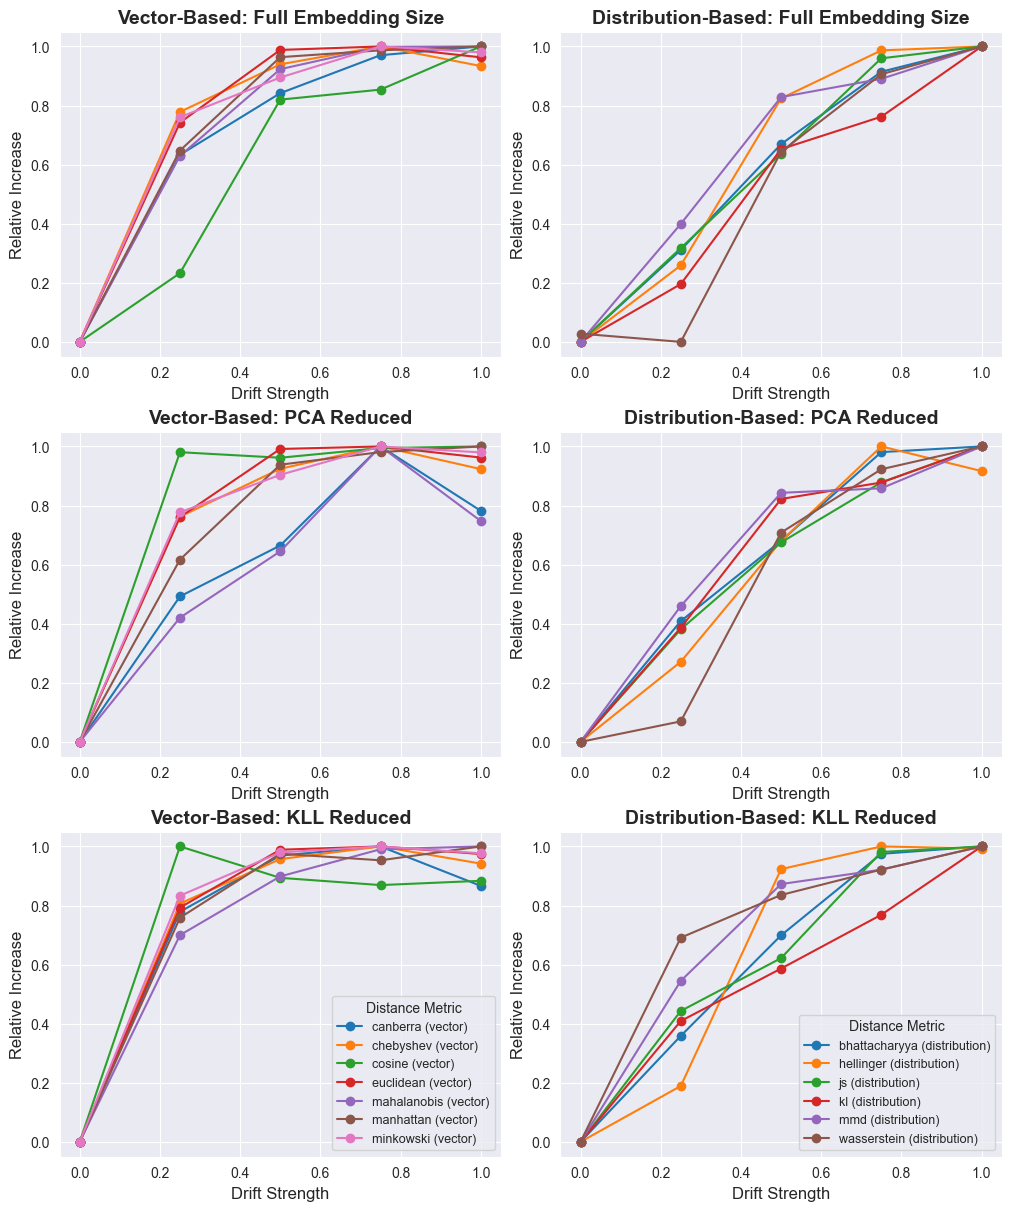

Plot saved to: /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_relative_log_increase_square.png


In [33]:
def plot_relative_log_increase(
    df,
    output_dir="/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment",
):
    plot_data = []

    for _, row in df.iterrows():
        if row["drift_strength"] >= 0:
            base_similarity_filter = [
                (df["drift_strength"] == 0),
                (df["distance_name"] == row["distance_name"]),
                (df["method"] == row["method"]),
            ]
            if "experiment_type" in df.columns and row["experiment_type"] is not None:
                base_similarity_filter.append(
                    df["experiment_type"] == row["experiment_type"]
                )

            base_similarity = df.loc[np.logical_and.reduce(base_similarity_filter)][
                "final_similarity"
            ].mean()

            if base_similarity and base_similarity > 0:
                rel_log = np.log(row["final_similarity"] / base_similarity)
                plot_data_row = {
                    "distance_name": row["distance_name"],
                    "drift_strength": row["drift_strength"],
                    "method": row["method"],
                    "distance_type": row["distance_type"],
                    "rel_log_increase": rel_log,
                }
                if "experiment_type" in df.columns:
                    plot_data_row["experiment_type"] = row["experiment_type"]
                plot_data.append(plot_data_row)

    df_plot = pd.DataFrame(plot_data)

    df_normalized = []
    groupby_cols = ["distance_name", "method"]
    if "experiment_type" in df_plot.columns:
        groupby_cols.append("experiment_type")

    for group_key, group in df_plot.groupby(groupby_cols):
        df_avg = (
            group.groupby("drift_strength")["rel_log_increase"].mean().reset_index()
        )
        min_val = df_avg["rel_log_increase"].min()
        max_val = df_avg["rel_log_increase"].max()
        if max_val - min_val > 1e-12:
            df_avg["normalized"] = (df_avg["rel_log_increase"] - min_val) / (
                max_val - min_val
            )
        else:
            df_avg["normalized"] = 0.0

        if "experiment_type" in df_plot.columns:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]
            df_avg["experiment_type"] = group_key[2]
        else:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]

        df_avg["distance_type"] = group["distance_type"].iloc[0]
        df_normalized.append(df_avg)

    df_final = pd.concat(df_normalized, ignore_index=True)

    fig, axes = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)

    method_positions = [
        # Row 1: Full Embedding
        ("no_pca", "Vector-Based: Full Embedding Size"),
        ("histogram", "Distribution-Based: Full Embedding Size"),
        # Row 2: PCA Reduced
        ("pca", "Vector-Based: PCA Reduced"),
        ("pca_histogram", "Distribution-Based: PCA Reduced"),
        # Row 3: KLL Reduced
        ("kll_vector", "Vector-Based: KLL Reduced"),
        ("kll_distribution", "Distribution-Based: KLL Reduced"),
    ]

    for ax, (method, title) in zip(axes.flat, method_positions):
        sub_df = df_final[df_final["method"] == method]

        if "experiment_type" in sub_df.columns:
            for dist_name in sub_df["distance_name"].unique():
                for exp_type in sub_df["experiment_type"].unique():
                    d = sub_df[
                        (sub_df["distance_name"] == dist_name)
                        & (sub_df["experiment_type"] == exp_type)
                    ]
                    if not d.empty:
                        label = f"{dist_name} ({exp_type})" if exp_type else dist_name
                        ax.plot(
                            d["drift_strength"],
                            d["normalized"],
                            marker="o",
                            label=label,
                        )
        else:
            for dist_name in sub_df["distance_name"].unique():
                d = sub_df[sub_df["distance_name"] == dist_name]
                if not d.empty:
                    ax.plot(
                        d["drift_strength"],
                        d["normalized"],
                        marker="o",
                        label=dist_name,
                    )

        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.set_xlabel("Drift Strength", fontsize=12)
        ax.set_ylabel("Relative Increase", fontsize=12)
        ax.tick_params(axis="both", labelsize=10)
        ax.grid(True)

        if (
            method in ["kll_vector", "kll_distribution"]
            and ax.get_legend_handles_labels()[0]
        ):
            ax.legend(title="Distance Metric", fontsize=9, title_fontsize=10)

    path_out = os.path.join(output_dir, "plot_relative_log_increase_square.png")
    plt.savefig(path_out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return path_out


# Generate plot
output_plot_path = plot_relative_log_increase(combined_df)
print(f"Plot saved to: {output_plot_path}")

In [16]:
"""
python plot_compression_tradeoffs.py --results_path /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/2025-04-18_12-02-01/results.json \
                                      --out_dir figs

The script is deterministic and has no external dependencies beyond
Pandas & Matplotlib.
"""
import argparse
import pathlib
from typing import List

import pandas as pd

# ────────────────────────────────────────────────────────────────────────────
# Helpers
# ────────────────────────────────────────────────────────────────────────────


def _flatten_records(obj: dict) -> List[dict]:
    """Flatten the nested {dataset}->{model}->[records] structure."""
    rows = []
    for dataset, model_map in obj.items():
        for model, records in model_map.items():
            for rec in records:
                rec = rec.copy()
                rec["dataset"] = dataset
                rec["model"] = model
                rows.append(rec)
    return rows


def _summarise(df: pd.DataFrame) -> pd.DataFrame:
    """Create the efficiency summary table used in the paper."""
    return (
        df
        # collapse seeds / datasets / distance names – we want *overall* view
        .groupby("method", as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            mean_final_similarity=("final_similarity", "mean"),
            mean_avg_overhead=("avg_overhead", "mean"),
            mean_time_taken=("time_taken", "mean"),
            mean_memory=("avg_memory_mb", "mean"),
            mean_peak_memory=("peak_memory_mb", "mean"),
        )
        .assign(
            speedup_vs_full=lambda d: d.loc[
                d.method == "no_pca", "mean_time_taken"
            ].iloc[0]
            / d["mean_time_taken"],
            memory_reduction=lambda d: d.loc[d.method == "no_pca", "mean_memory"].iloc[
                0
            ]
            / d["mean_memory"],
        )
        .rename(
            columns={
                "method": "Method",
                "mean_accuracy": "Accuracy",
                "mean_final_similarity": "DetectionAccuracy",  # alias for clarity
                "mean_avg_overhead": "AvgOverhead_s",
                "mean_time_taken": "TotalRuntime_s",
                "mean_memory": "AvgMem_MB",
                "mean_peak_memory": "PeakMem_MB",
            }
        )
        .sort_values("AvgMem_MB")
    )


# ────────────────────────────────────────────────────────────────────────────
# Plotting
# ────────────────────────────────────────────────────────────────────────────


def _plot_tradeoffs(df, output_dir):
    """Plots tradeoffs between two metrics (e.g., accuracy vs. memory usage) for different methods."""
    # Define figure size and layout
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define color palette
    palette = sns.color_palette("Set2", len(df["method"].unique()))

    # Plot each method
    for i, method in enumerate(df["method"].unique()):
        subset = df[df["method"] == method]
        ax.plot(
            subset["metric_x"],  # Replace with the x-axis metric
            subset["metric_y"],  # Replace with the y-axis metric
            marker="o",
            label=method,
            color=palette[i % len(palette)],
        )

    # Set title, labels, and grid
    ax.set_title(
        "Tradeoff Between Metric X and Metric Y", fontsize=16, fontweight="bold"
    )
    ax.set_xlabel("Metric X", fontsize=14)
    ax.set_ylabel("Metric Y", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.7)

    # Style ticks
    ax.tick_params(axis="both", labelsize=12)

    # Add legend
    ax.legend(title="Method", fontsize=12, title_fontsize=13, loc="best")

    # Save and show the plot
    path_out = os.path.join(output_dir, "plot_tradeoffs.png")
    plt.tight_layout()
    plt.savefig(path_out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[Saved] {path_out}")


# ────────────────────────────────────────────────────────────────────────────
# Main
# ────────────────────────────────────────────────────────────────────────────


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument(
        "--results_path",
        required=True,
        help="Path to results.json produced by the experiment script",
    )
    ap.add_argument(
        "--out_dir", default="figs", help="Directory to store CSV and PNG outputs"
    )
    args = ap.parse_args()

    out_dir = pathlib.Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(args.results_path) as f:
        raw = json.load(f)
    rows = _flatten_records(raw)
    df = pd.DataFrame(rows)

    summary = _summarise(df)
    csv_path = out_dir / "compression_summary.csv"
    summary.to_csv(csv_path, index=False)
    print(f"[✓] Summary table written to {csv_path}")

    png_path = out_dir / "compression_tradeoffs.png"
    _plot_tradeoffs(summary, png_path)
    print(f"[✓] Figure written to {png_path}")


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] --results_path RESULTS_PATH
                             [--out_dir OUT_DIR]
ipykernel_launcher.py: error: the following arguments are required: --results_path


SystemExit: 2

/Users/jasper.bruin/miniconda3/envs/driftwatch-new/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
